<a href="https://colab.research.google.com/github/DikshyaL/DL-practical-lab/blob/main/COMP488_PL4_Dikshya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN for Image Classification

**Student Name:** Dikshya Lamichhane  
**Course:** COMP488 Neural Network and Deep Learning  
**Submission Date:** 26/04/2026  
**Dataset Used:** Fashion-MNIST  

## Objective

- To build a Convolutional Neural Network (CNN) for image classification using the Fashion-MNIST dataset.
- To understand how convolution and pooling help in extracting spatial features from images.
- To compare CNN performance with a simple Multi-Layer Perceptron (MLP) baseline.
- To evaluate the model using accuracy, confusion matrix, and sample predictions.
- To visualize feature maps learned by the CNN.


## Theoretical Background

A Convolutional Neural Network (CNN) is a deep learning model designed for image data. Unlike a fully connected neural network, a CNN preserves the spatial structure of images by using convolution filters that learn local patterns such as edges, shapes, and textures.

### Key Concepts
- **Convolution Layer:** Applies small learnable filters to detect local features.
- **Pooling Layer:** Reduces the spatial size of feature maps and helps make the model more efficient.
- **Activation Function:** ReLU is commonly used to introduce non-linearity.
- **Fully Connected Layer:** Combines extracted features to produce final class predictions.

### Why CNN works better for images
CNNs are effective because nearby pixels in an image are related, and convolution keeps this local information. Weight sharing also reduces the number of parameters compared to a fully connected network.

### Basic idea
If an input image is \(28 \times 28\), the CNN learns:
1. low-level features in early layers,
2. more complex patterns in deeper layers,
3. final class probabilities at the output layer.
### Convolution idea
A convolution operation can be written as:

\[
Y(i,j) = \sum_m \sum_n X(i+m, j+n) \cdot K(m,n)
\]

where \(X\) is the input image and \(K\) is the filter/kernel.

## Dataset Description

The dataset used in this assignment is **Fashion-MNIST**, which contains grayscale images of clothing items.

### Source
- Fashion-MNIST dataset from torchvision.

### Dataset details
- Total training samples: 60,000
- Total test samples: 10,000
- Image size: 28 x 28 pixels
- Number of classes: 10

### Classes
- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

### Train/test split strategy
- The original training set is reduced to a smaller subset for faster training.
- A validation split is created from the reduced training subset.
- The test set is kept unchanged for final evaluation.


In [1]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
# Loading Dataset

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)


subset_size = 10000
indices = torch.randperm(len(train_full))[:subset_size]
train_subset = torch.utils.data.Subset(train_full, indices)

train_size = int(0.9 * len(train_subset))
val_size = len(train_subset) - train_size
train_set, val_set = random_split(train_subset, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.83MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 142kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.0MB/s]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


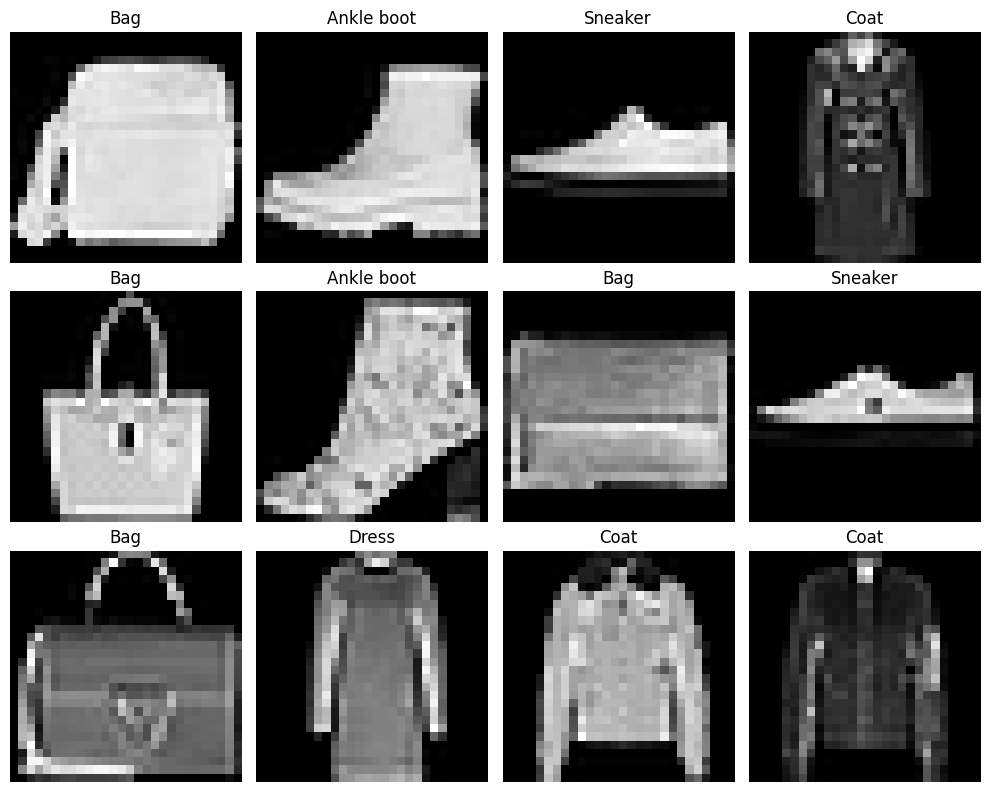

In [3]:
def denormalize(img):
    return img * 0.5 + 0.5

def show_samples(loader, n=12):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(3, 4, figsize=(10, 8))
    for i, ax in enumerate(axes.flat[:n]):
        img = denormalize(images[i]).squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(class_names[labels[i]])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_loader)

In [4]:
class CNNModel(nn.Module):
    def __init__(self, conv1=32, conv2=64, conv3=128, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, conv1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(conv1, conv2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(conv2, conv3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv3 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class MLPModel(nn.Module):
    def __init__(self, hidden1=512, hidden2=256, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

def evaluate(model, loader, criterion=None):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if criterion is not None:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total if criterion is not None else None
    acc = correct / total
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

def fit_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val = 0
    best_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_state = model.state_dict()

        print(f"Epoch {epoch+1}/{epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [6]:
# Experiment 1: Baseline CNN
cnn = CNNModel(conv1=32, conv2=64, conv3=128, dropout=0.5)
cnn, cnn_history = fit_model(cnn, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss=1.2020 train_acc=0.5571 | val_loss=0.6418 val_acc=0.7610
Epoch 2/10 | train_loss=0.6873 train_acc=0.7457 | val_loss=0.5323 val_acc=0.7950
Epoch 3/10 | train_loss=0.5806 train_acc=0.7811 | val_loss=0.4870 val_acc=0.8160
Epoch 4/10 | train_loss=0.5173 train_acc=0.8114 | val_loss=0.4804 val_acc=0.8170
Epoch 5/10 | train_loss=0.4716 train_acc=0.8279 | val_loss=0.4070 val_acc=0.8380
Epoch 6/10 | train_loss=0.4261 train_acc=0.8430 | val_loss=0.3919 val_acc=0.8510
Epoch 7/10 | train_loss=0.4033 train_acc=0.8521 | val_loss=0.3763 val_acc=0.8460
Epoch 8/10 | train_loss=0.3699 train_acc=0.8621 | val_loss=0.3591 val_acc=0.8590
Epoch 9/10 | train_loss=0.3530 train_acc=0.8709 | val_loss=0.3961 val_acc=0.8340
Epoch 10/10 | train_loss=0.3387 train_acc=0.8759 | val_loss=0.3490 val_acc=0.8710


In [7]:
# MLP baseline
mlp = MLPModel(hidden1=512, hidden2=256, dropout=0.5)
mlp, mlp_history = fit_model(mlp, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss=1.0074 train_acc=0.6273 | val_loss=0.6054 val_acc=0.7720
Epoch 2/10 | train_loss=0.6490 train_acc=0.7592 | val_loss=0.5014 val_acc=0.8190
Epoch 3/10 | train_loss=0.5652 train_acc=0.7918 | val_loss=0.4985 val_acc=0.8140
Epoch 4/10 | train_loss=0.5275 train_acc=0.8056 | val_loss=0.4689 val_acc=0.8330
Epoch 5/10 | train_loss=0.4997 train_acc=0.8147 | val_loss=0.4671 val_acc=0.8230
Epoch 6/10 | train_loss=0.4853 train_acc=0.8221 | val_loss=0.4402 val_acc=0.8270
Epoch 7/10 | train_loss=0.4529 train_acc=0.8336 | val_loss=0.4288 val_acc=0.8270
Epoch 8/10 | train_loss=0.4466 train_acc=0.8390 | val_loss=0.4290 val_acc=0.8330
Epoch 9/10 | train_loss=0.4180 train_acc=0.8437 | val_loss=0.4258 val_acc=0.8370
Epoch 10/10 | train_loss=0.4339 train_acc=0.8439 | val_loss=0.4080 val_acc=0.8490


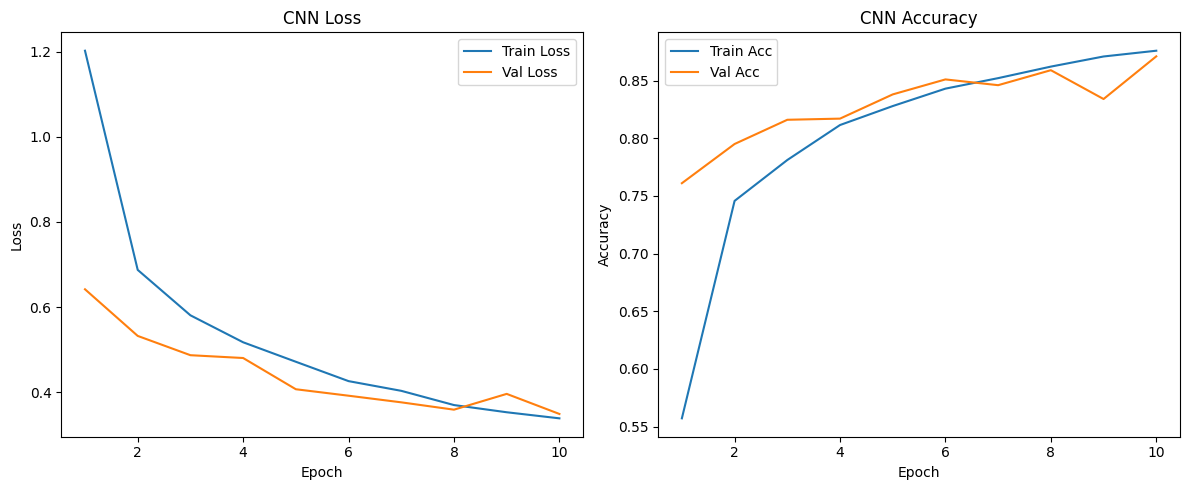

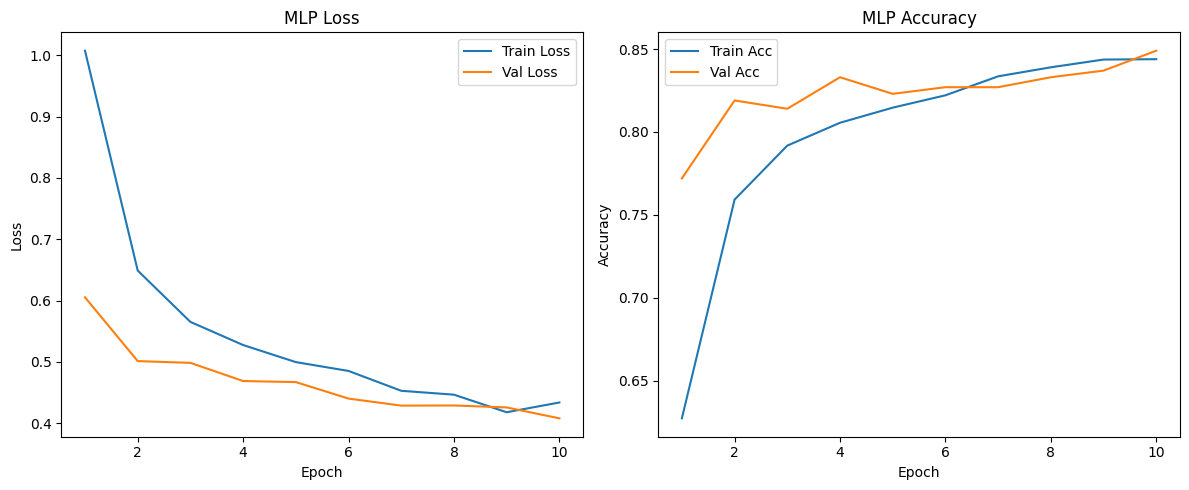

In [8]:
def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(cnn_history, "CNN")
plot_history(mlp_history, "MLP")

In [9]:
cnn_test_loss, cnn_test_acc, y_true_cnn, y_pred_cnn = evaluate(cnn, test_loader, nn.CrossEntropyLoss())
mlp_test_loss, mlp_test_acc, y_true_mlp, y_pred_mlp = evaluate(mlp, test_loader, nn.CrossEntropyLoss())

print("CNN Test Accuracy:", cnn_test_acc)
print("MLP Test Accuracy:", mlp_test_acc)

CNN Test Accuracy: 0.8663
MLP Test Accuracy: 0.8431


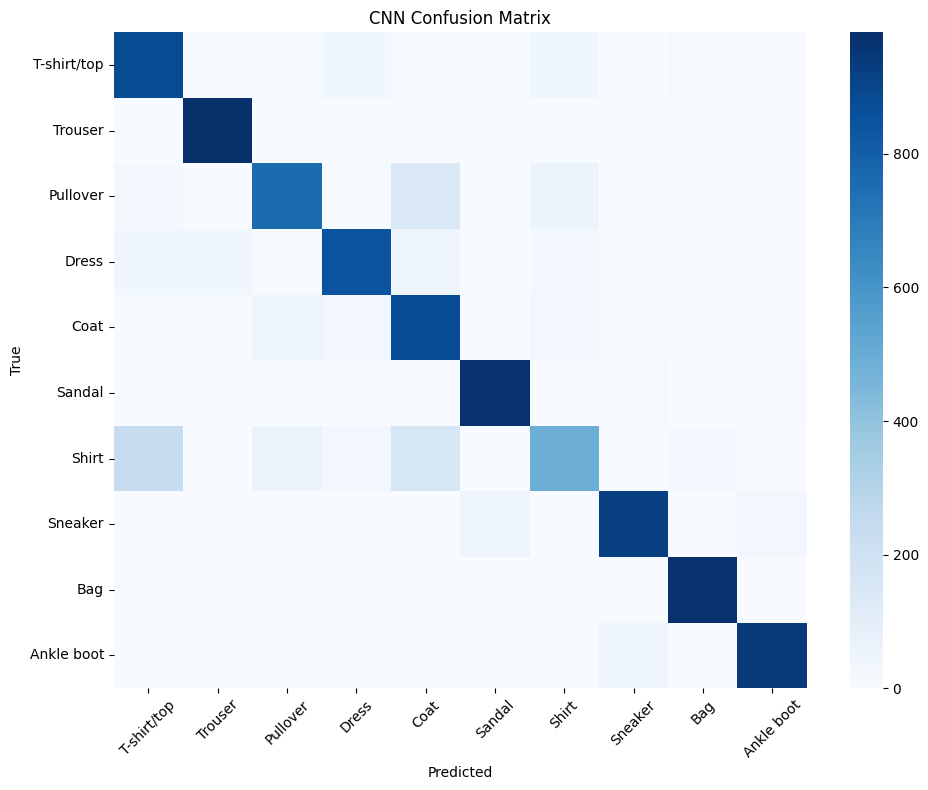

In [10]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(y_true_cnn, y_pred_cnn, "CNN Confusion Matrix")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


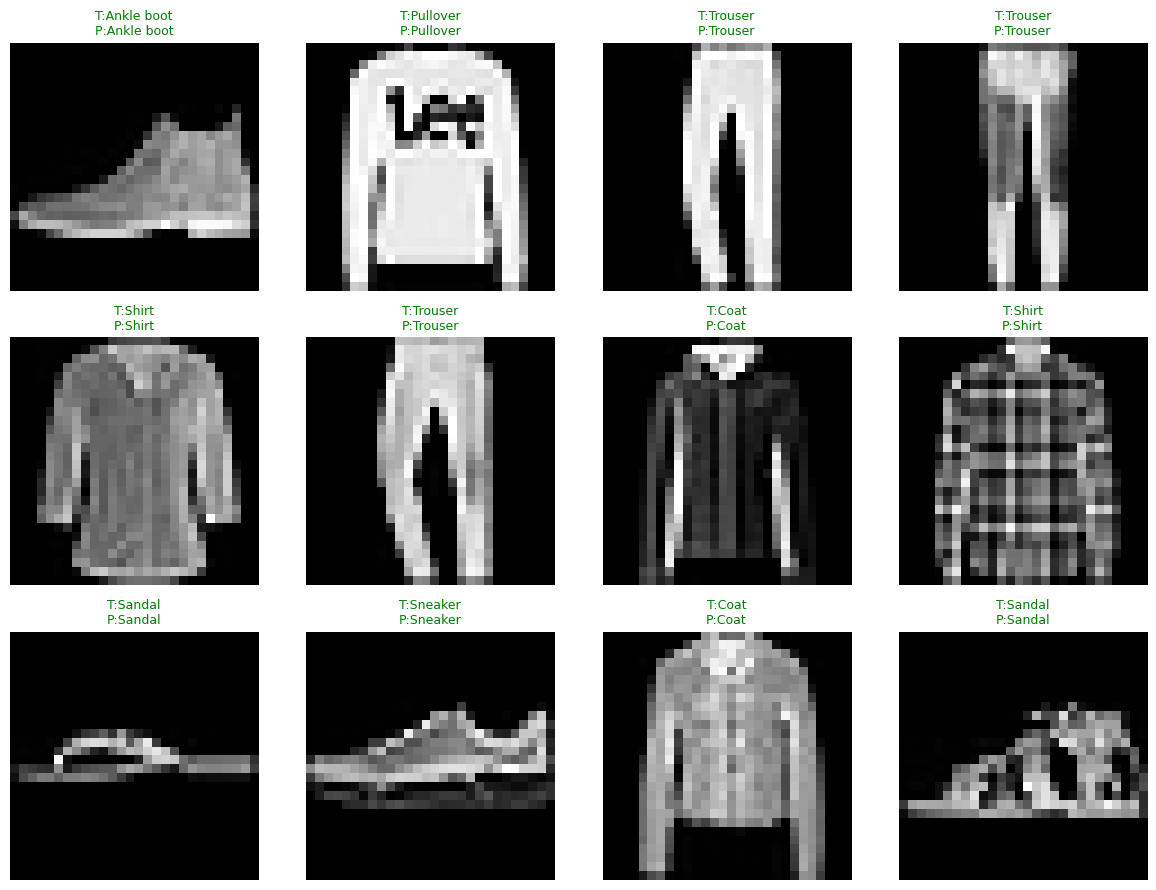

In [11]:
def show_predictions(model, loader, n=12):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for i, ax in enumerate(axes.flat[:n]):
        img = denormalize(images[i].cpu()).squeeze().numpy()
        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]
        color = 'green' if true_label == pred_label else 'red'
        ax.imshow(img, cmap='gray')
        ax.set_title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(cnn, test_loader)

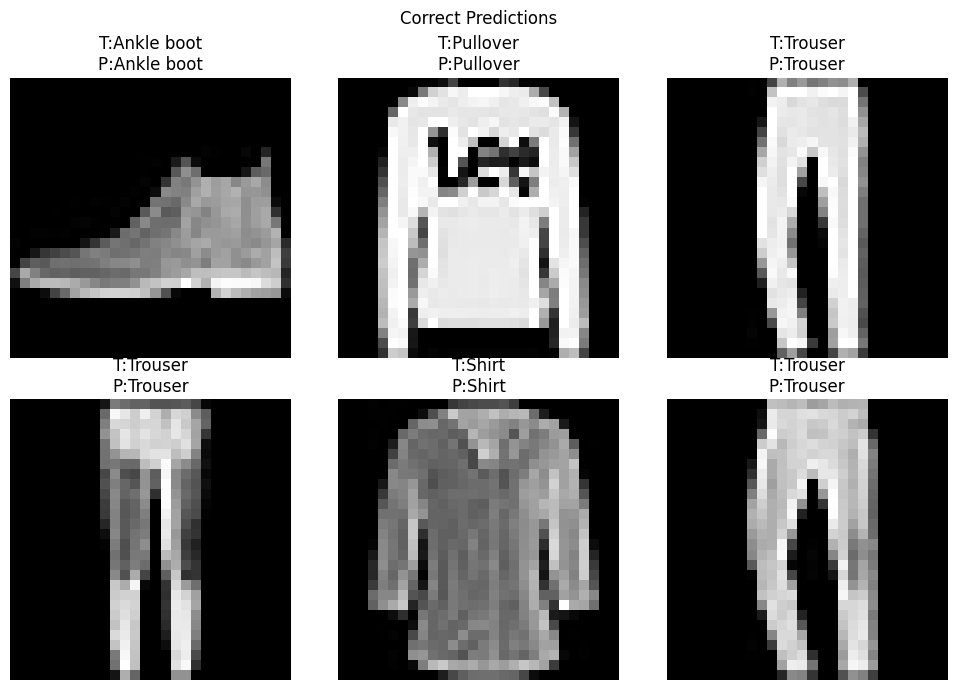

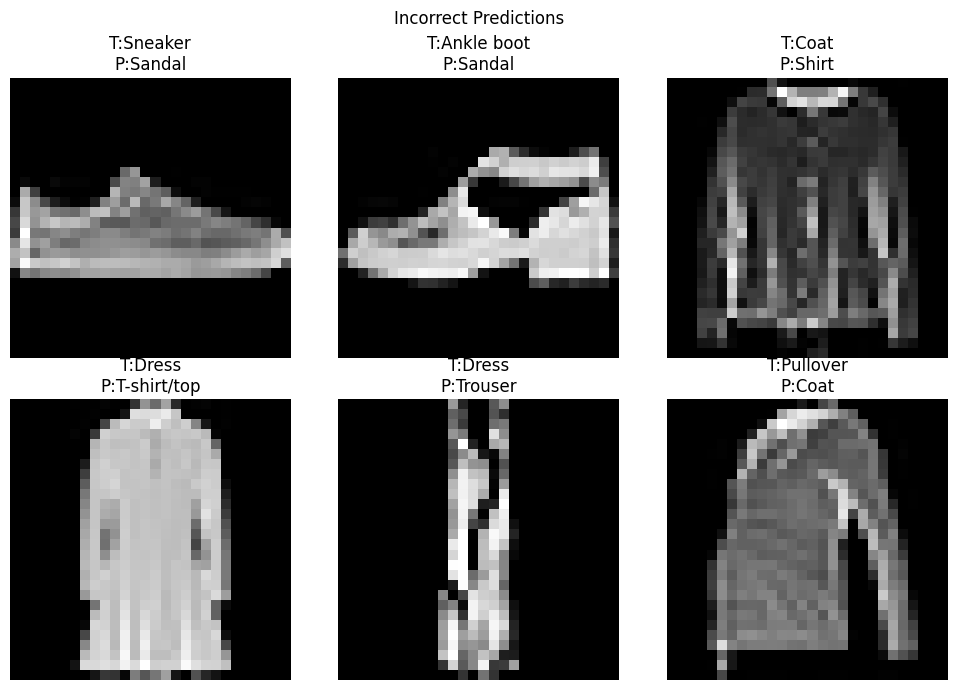

In [12]:
def get_correct_incorrect(model, loader):
    model.eval()
    correct = []
    incorrect = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            for i in range(len(labels)):
                item = {
                    'image': images[i].cpu(),
                    'true': labels[i].item(),
                    'pred': preds[i].item()
                }
                if labels[i].item() == preds[i].item():
                    correct.append(item)
                else:
                    incorrect.append(item)

            if len(correct) >= 6 and len(incorrect) >= 6:
                break

    return correct[:6], incorrect[:6]

correct_samples, incorrect_samples = get_correct_incorrect(cnn, test_loader)

def plot_sample_list(samples, title):
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for ax, item in zip(axes.flat, samples):
        img = denormalize(item['image']).squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"T:{class_names[item['true']]}\nP:{class_names[item['pred']]}")
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_sample_list(correct_samples, "Correct Predictions")
plot_sample_list(incorrect_samples, "Incorrect Predictions")

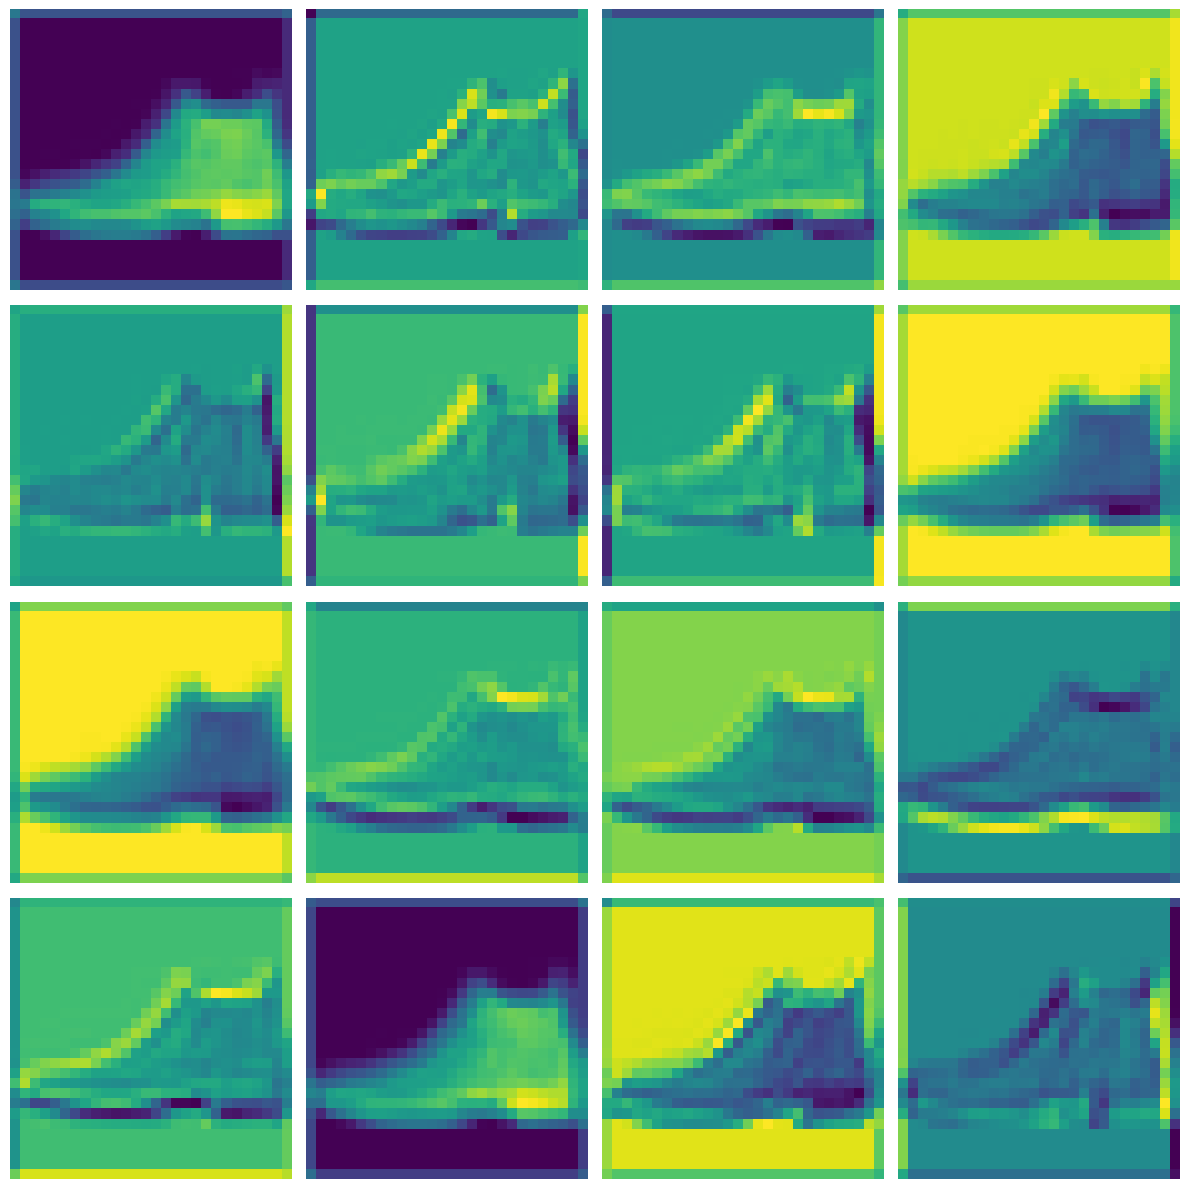

In [13]:
def get_feature_maps(model, image, layer_index=0):
    model.eval()
    activations = []

    def hook_fn(module, input, output):
        activations.append(output.detach().cpu())

    conv_layers = [m for m in model.features if isinstance(m, nn.Conv2d)]
    handle = conv_layers[layer_index].register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))

    handle.remove()
    return activations[0].squeeze(0)

sample_image, sample_label = test_set[0]
feature_maps = get_feature_maps(cnn, sample_image, layer_index=0)

def plot_feature_maps(feature_maps, n=16):
    n = min(n, feature_maps.shape[0])
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_maps[i], cmap='viridis')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps, n=16)

In [14]:
print("CNN classification report:\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

print("MLP classification report:\n")
print(classification_report(y_true_mlp, y_pred_mlp, target_names=class_names))

CNN classification report:

              precision    recall  f1-score   support

 T-shirt/top       0.74      0.88      0.81      1000
     Trouser       0.95      0.98      0.96      1000
    Pullover       0.84      0.76      0.80      1000
       Dress       0.87      0.85      0.86      1000
        Coat       0.71      0.88      0.78      1000
      Sandal       0.94      0.98      0.96      1000
       Shirt       0.77      0.49      0.60      1000
     Sneaker       0.94      0.92      0.93      1000
         Bag       0.95      0.98      0.96      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000

MLP classification report:

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.81      0.81      1000
     Trouser       0.96      0.96      0.96      1000
    Pullover       0.7

## Experiments

| Experiment | Model Setup | Purpose |
|-----------|-------------|---------|
| 1 | CNN with 32-64-128 filters, dropout 0.5 | Baseline CNN |
| 2 | CNN with 16-32-64 filters, dropout 0.5 | Faster/smaller model |
| 3 | CNN with dropout 0.3 | Check effect of less regularization |
| 4 | MLP baseline | Compare CNN with non-convolutional model |

In [15]:
experiments = [
    {"name": "CNN_32_64_128", "conv1": 32, "conv2": 64, "conv3": 128, "dropout": 0.5},
    {"name": "CNN_64_128_256", "conv1": 64, "conv2": 128, "conv3": 256, "dropout": 0.5},
    {"name": "CNN_low_dropout", "conv1": 32, "conv2": 64, "conv3": 128, "dropout": 0.3},
]

results = []
for exp in experiments:
    model = CNNModel(exp["conv1"], exp["conv2"], exp["conv3"], exp["dropout"])
    model, hist = fit_model(model, train_loader, val_loader, epochs=8, lr=1e-3)
    _, test_acc, _, _ = evaluate(model, test_loader, nn.CrossEntropyLoss())
    results.append([exp["name"], test_acc])

results



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/8 | train_loss=1.2181 train_acc=0.5477 | val_loss=0.6618 val_acc=0.7310
Epoch 2/8 | train_loss=0.6984 train_acc=0.7446 | val_loss=0.5412 val_acc=0.7940
Epoch 3/8 | train_loss=0.5881 train_acc=0.7850 | val_loss=0.4877 val_acc=0.8120
Epoch 4/8 | train_loss=0.5175 train_acc=0.8134 | val_loss=0.4469 val_acc=0.8330
Epoch 5/8 | train_loss=0.4806 train_acc=0.8261 | val_loss=0.4301 val_acc=0.8350
Epoch 6/8 | train_loss=0.4384 train_acc=0.8423 | val_loss=0.4058 val_acc=0.8380
Epoch 7/8 | train_loss=0.4134 train_acc=0.8502 | val_loss=0.4110 val_acc=0.8350
Epoch 8/8 | train_loss=0.3865 train_acc=0.8580 | val_loss=0.4041 val_acc=0.8480
Epoch 1/8 | train_loss=1.1402 train_acc=0.5920 | val_loss=0.6403 val_acc=0.7620
Epoch 2/8 | train_loss=0.6263 train_acc=0.7727 | val_loss=0.5118 val_acc=0.8010
Epoch 3/8 | train_loss=0.5208 train_acc=0.8164 | val_loss=0.4344 val_acc=0.8320
Epoch 4/8 | train_loss=0.4519 train_acc=0.8392 | val_loss=0.4078 val_acc=0.8360
Epoch 5/8 | train_loss=0.4106 train_acc=

[['CNN_32_64_128', 0.8514],
 ['CNN_64_128_256', 0.8803],
 ['CNN_low_dropout', 0.8642]]

## Results

The CNN performed better than the MLP baseline on Fashion-MNIST, with a test accuracy of 0.8663 compared to 0.8431. The best experiment was CNN_64_128_256, which achieved 0.8803 test accuracy.

| Model | Test Acc |
|---|---:|
| CNN baseline | 0.8663 |
| MLP baseline | 0.8431 |
| CNN_32_64_128 | 0.8514 |
| CNN_64_128_256 | 0.8803 |
| CNN_low_dropout | 0.8642 |

The CNN showed better class-wise performance overall, especially on Trouser, Sandal, Bag, and Ankle boot. Shirt was the hardest class for both models.

## Analysis & Discussion

The CNN outperformed the MLP because convolution layers preserve spatial information in images. Fashion-MNIST has local patterns like edges and shapes, which CNNs learn better than a flattened MLP input.

The best model was CNN_64_128_256 because it had more filters and learned richer features. The improvement was not huge, so the baseline CNN was already strong.

There was only mild overfitting since training accuracy was slightly higher than validation accuracy. Shirt remained the most difficult class because it looks similar to other clothing categories.

### What worked well
- CNN instead of MLP.
- Pooling layers.
- Dropout.
- Trying multiple filter sizes.

### What did not work as well
- MLP was weaker.
- Shirt classification was difficult.
- Larger models helped only slightly.

## Conclusion

- CNN worked better than MLP for Fashion-MNIST.
- Best test accuracy was 0.8803 from CNN_64_128_256.
- Convolution and pooling helped learn image features well.
- The model performed best on clearly different classes.
- Shirt was the hardest class to classify.
- CNN is more suitable than MLP for image classification.